# Training Pipeline

In [5]:
# Install this once
!pip install import-ipynb
!pip install import-ipynb scikit-learn

# DataLoader import from Preprocessing_Pipeline

Cleaning datasets using class-wise autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 49.3373


Class 0 Epoch 2, Total Loss: 35.0855


Class 0 Epoch 3, Total Loss: 34.3676


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 6.7524


Class 2 Epoch 2, Total Loss: 6.7009


Class 2: removed 5 samples
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 4953
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.005743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0855688].


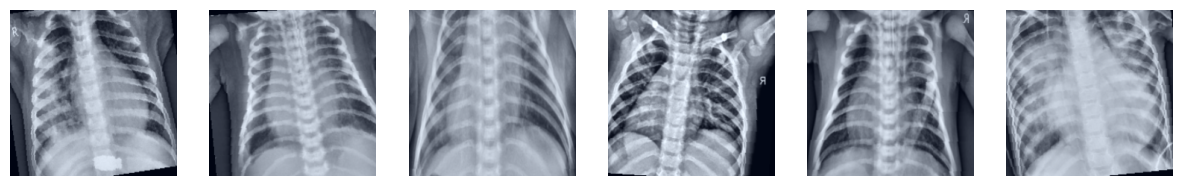

In [8]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [9]:
from torch.utils.data import DataLoader
 
train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


# EfficientNet-B4 Model Creation

In [11]:
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b4(
    weights=models.EfficientNet_B4_Weights.DEFAULT
)

num_classes = len(prep.train_dataset.classes)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

In [12]:
# 🔥 Freeze all
for param in model.parameters():
    param.requires_grad = False

# Train classifier first
for param in model.classifier.parameters():
    param.requires_grad = True

In [13]:
from collections import Counter

counts = Counter(prep.train_dataset.targets)
total = sum(counts.values())
class_weights = [total / counts[i] for i in range(len(counts))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Training Validation Parameters

In [14]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.3
)

EPOCHS = 20
FREEZE_EPOCHS = 3
PATIENCE = 4

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = copy.deepcopy(model.state_dict())

# ✅ AMP only if CUDA
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

C:\Users\noora\AppData\Local\Temp\ipykernel_33988\1725517783.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


# Training Loop

In [15]:
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader), correct / total

C:\Users\noora\AppData\Local\Temp\ipykernel_33988\2153968157.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


# Evaluation Loop

In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

# legends


Epoch 1/20


Training:   0%|          | 0/155 [00:00<?, ?it/s]C:\Users\noora\AppData\Local\Temp\ipykernel_33988\2153968157.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                                      

Train Loss: 1.0947 | Train Acc: 0.4084
Val   Loss: 1.0881 | Val   Acc: 0.5323
✅ Best model updated


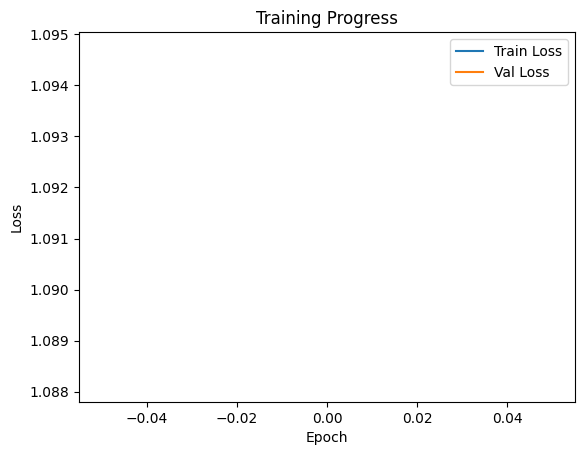


Epoch 2/20


Train Loss: 1.0813 | Train Acc: 0.5694
Val   Loss: 1.0796 | Val   Acc: 0.5860
✅ Best model updated


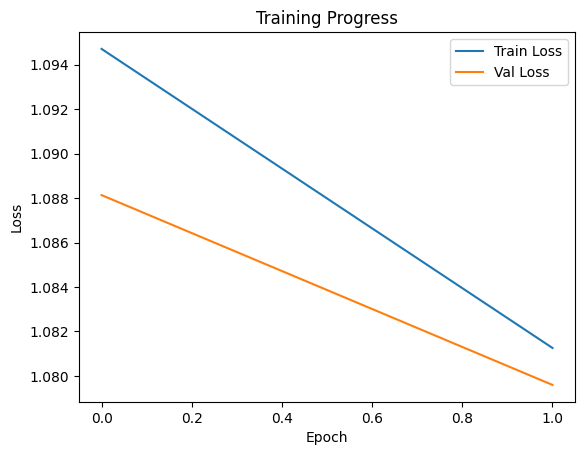


Epoch 3/20


Train Loss: 1.0751 | Train Acc: 0.6497
Val   Loss: 1.0753 | Val   Acc: 0.5215
✅ Best model updated


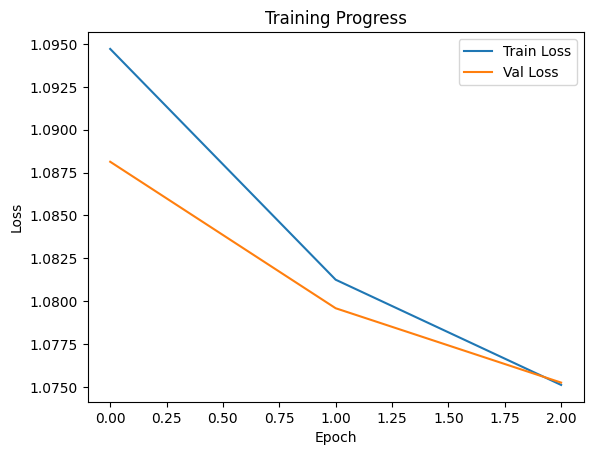


Epoch 4/20
🚀 Unfreezing backbone...


Train Loss: 1.0726 | Train Acc: 0.6160
Val   Loss: 1.0730 | Val   Acc: 0.5860
✅ Best model updated


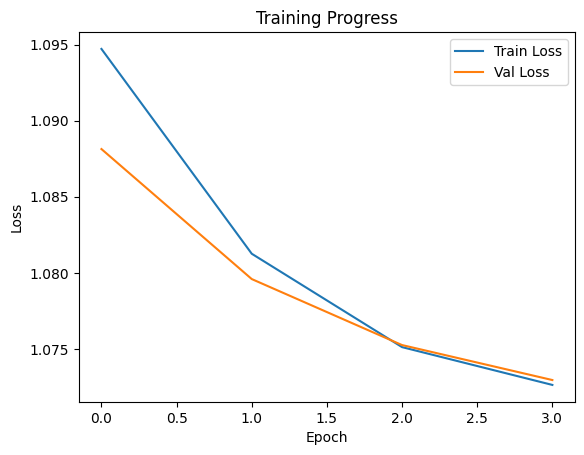


Epoch 5/20


Train Loss: 1.0723 | Train Acc: 0.6144
Val   Loss: 1.0736 | Val   Acc: 0.5753
⚠️ No improvement for 1 epochs


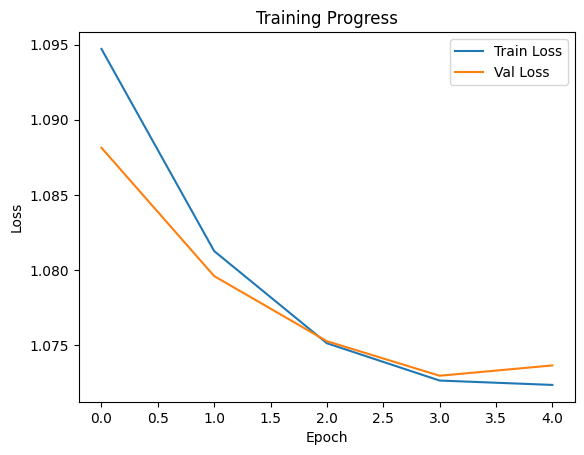


Epoch 6/20


Train Loss: 1.0717 | Train Acc: 0.6200
Val   Loss: 1.0733 | Val   Acc: 0.5323
⚠️ No improvement for 2 epochs


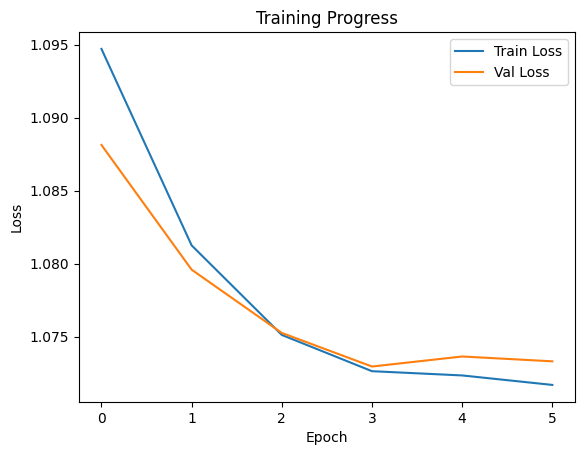


Epoch 7/20


Train Loss: 1.0714 | Train Acc: 0.6315
Val   Loss: 1.0729 | Val   Acc: 0.5430
✅ Best model updated


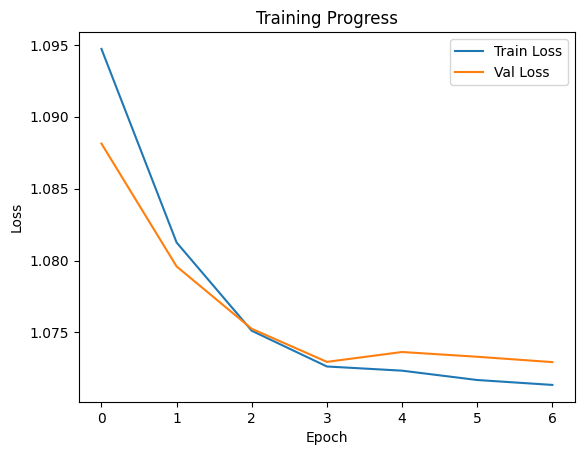


Epoch 8/20


Train Loss: 1.0710 | Train Acc: 0.6317
Val   Loss: 1.0719 | Val   Acc: 0.5806
✅ Best model updated


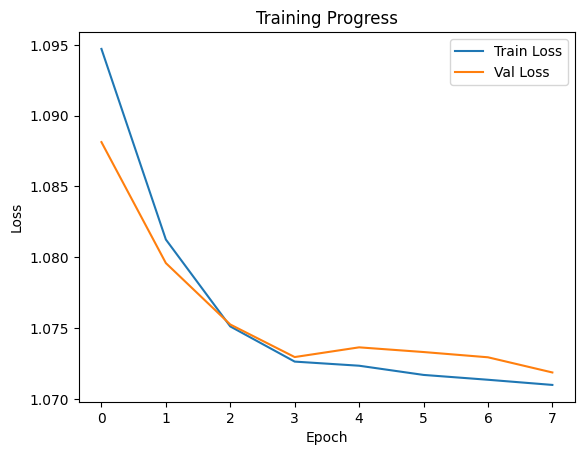


Epoch 9/20


Train Loss: 1.0708 | Train Acc: 0.6239
Val   Loss: 1.0737 | Val   Acc: 0.5376
⚠️ No improvement for 1 epochs


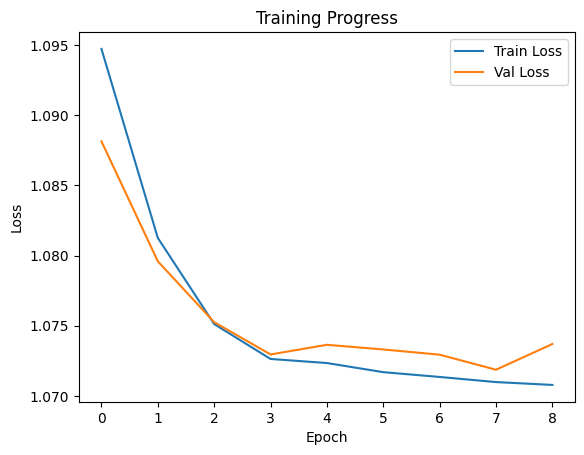


Epoch 10/20


Train Loss: 1.0709 | Train Acc: 0.6253
Val   Loss: 1.0733 | Val   Acc: 0.5484
⚠️ No improvement for 2 epochs


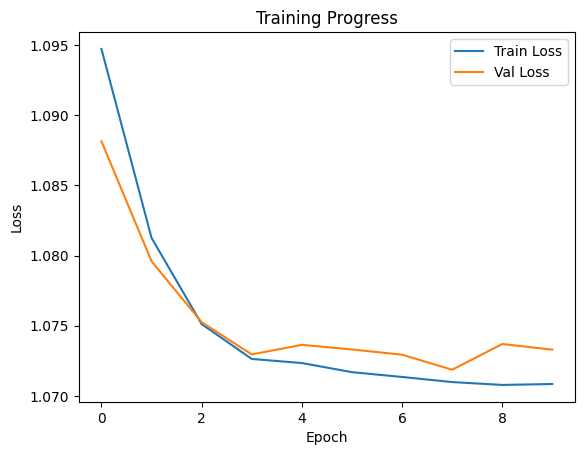


Epoch 11/20


Train Loss: 1.0705 | Train Acc: 0.6273
Val   Loss: 1.0732 | Val   Acc: 0.5376
⚠️ No improvement for 3 epochs


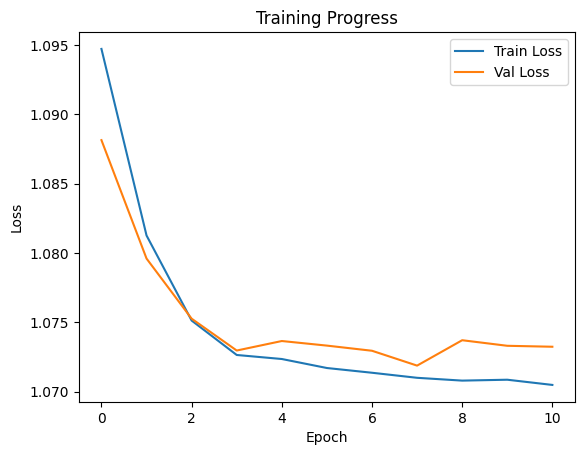


Epoch 12/20


Train Loss: 1.0706 | Train Acc: 0.6271
Val   Loss: 1.0714 | Val   Acc: 0.5806
✅ Best model updated


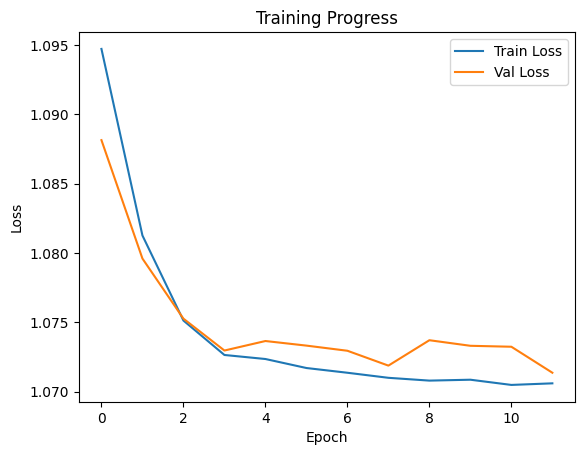


Epoch 13/20


Train Loss: 1.0705 | Train Acc: 0.6200
Val   Loss: 1.0725 | Val   Acc: 0.5645
⚠️ No improvement for 1 epochs


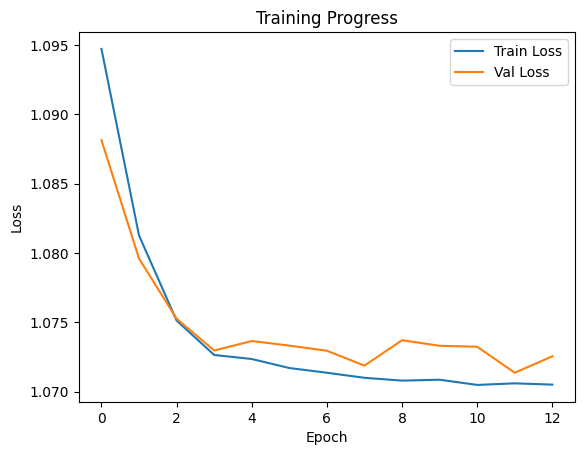


Epoch 14/20


Train Loss: 1.0702 | Train Acc: 0.6257
Val   Loss: 1.0739 | Val   Acc: 0.5645
⚠️ No improvement for 2 epochs


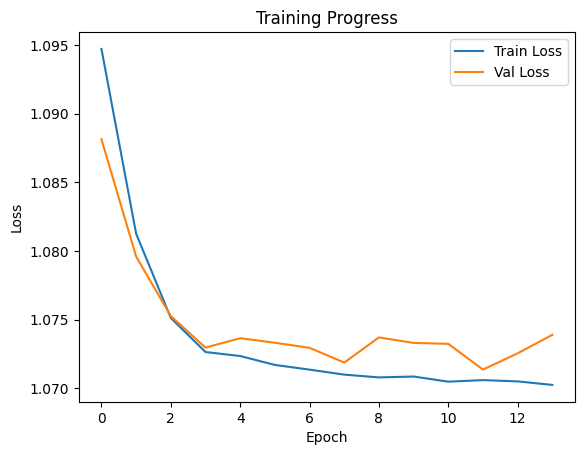


Epoch 15/20


Train Loss: 1.0716 | Train Acc: 0.6174
Val   Loss: 1.0737 | Val   Acc: 0.5538
⚠️ No improvement for 3 epochs


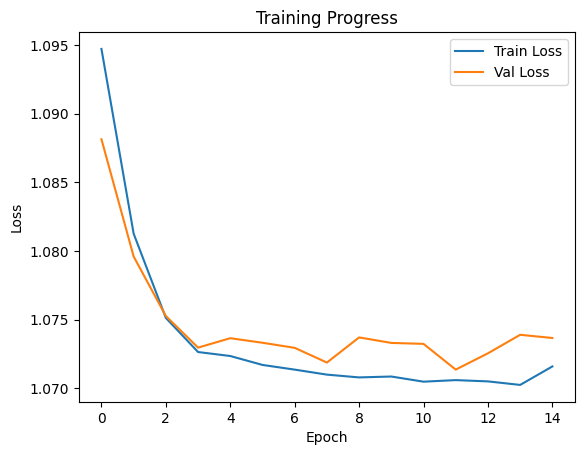


Epoch 16/20


Train Loss: 1.0723 | Train Acc: 0.6216
Val   Loss: 1.0738 | Val   Acc: 0.5538
⚠️ No improvement for 4 epochs
🛑 Early stopping triggered


In [17]:
plt.ion()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    if epoch == FREEZE_EPOCHS:
        print("🚀 Unfreezing backbone...")

        for param in model.features[-4:].parameters():
            param.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), 
            lr=1e-5,
            weight_decay=1e-4
        )

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=2, factor=0.3
        )

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # 🔥 EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("✅ Best model updated")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

    # 📊 LIVE GRAPH
    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Progress")
    plt.pause(0.1)

plt.ioff()
plt.show()

# Save Best Model

In [23]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [24]:
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("\nTest Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")


Test Results:
Loss: 1.0801
Accuracy: 0.6358


In [25]:
from sklearn.metrics import f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 🔥 F1 Score
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6162


In [26]:
torch.save(model.state_dict(), "EfficientNet-B4_pneumonia.pth")

import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=prep.train_dataset.classes))

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.86      0.55      0.67       234
             NORMAL       0.54      0.94      0.68       227
    VIRAL_PNEUMONIA       0.72      0.29      0.42       143

           accuracy                           0.64       604
          macro avg       0.71      0.59      0.59       604
       weighted avg       0.71      0.64      0.62       604

